In [1]:
!pip -q install lifelines scikit-survival chronos-forecasting

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 15.5 MB/s eta 0:00:00


# VERİ

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.special import gamma as gammafn
from lifelines import NelsonAalenFitter
from lifelines.utils import concordance_index
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from chronos import ChronosPipeline

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

raw = sm.datasets.get_rdataset("faithful", "datasets").data
T = np.cumsum(raw["eruptions"].to_numpy(float) + raw["waiting"].to_numpy(float))
E = pd.DataFrame({"T": T, "delta": np.ones(len(T))})

tau = np.diff(E["T"].to_numpy())
delta = E["delta"].to_numpy()[1:]
T_prev = E["T"].to_numpy()[:-1]

L = 32
H = 40
P = 0.5

X = np.stack([tau[i - L:i] for i in range(L, len(tau))])
y = tau[L:]
d = delta[L:]
Tp = T_prev[L:]

n_tr = len(y) - H
X_tr, X_te = X[:n_tr], X[n_tr:]
y_tr, y_te = y[:n_tr], y[n_tr:]
d_tr, d_te = d[:n_tr], d[n_tr:]
Tp_te = Tp[n_tr:]
T_te = Tp_te + y_te

TAU_HAT = {}
T_HAT = {}

pd.DataFrame({"n_olay": [len(E)], "n_tau": [len(tau)], "L": [L],
              "n_train": [len(y_tr)], "n_test": [len(y_te)],
              "tau_ort": [tau.mean()], "tau_std": [tau.std()]}).round(3)

,n_olay,n_tau,L,n_train,n_test,tau_ort,tau_std
0,272,271,32,199,40,74.355,14.623


# MODEL

## Deterministik

In [3]:
naf = NelsonAalenFitter()
naf.fit(y_tr, event_observed=d_tr)

grid = naf.cumulative_hazard_.index.to_numpy()
Lam = naf.cumulative_hazard_.to_numpy().ravel()
S = np.exp(-Lam)
F = 1.0 - S

q = min(int(np.searchsorted(F, P)), len(grid) - 1)
tau_hat = np.full(H, float(grid[q]))

TAU_HAT["Deterministik"] = tau_hat
T_HAT["Deterministik"] = Tp_te + tau_hat

pd.Series({"tau_hat": float(grid[q]), "S": float(S[q]), "F": float(F[q])}).round(4)

,0
tau_hat,80.3330
S,0.4987
F,0.5013


## Stokastik

In [4]:
def log_psi(theta, x):
    w, a, b = theta[0], theta[1], theta[2]
    lx = np.log(x)
    lp = np.empty(len(x))
    lp[0] = np.log(x.mean())
    for t in range(1, len(x)):
        lp[t] = w + a * lx[t - 1] + b * lp[t - 1]
    return np.clip(lp, -10.0, 10.0)


def acd_nll(theta, x):
    k = float(np.exp(np.clip(theta[3], -5.0, 5.0)))
    lam = np.exp(log_psi(theta, x)) / gammafn(1.0 + 1.0 / k)
    z = x / lam
    v = np.log(k) - np.log(lam) + (k - 1.0) * np.log(z) - z ** k
    if not np.all(np.isfinite(v)):
        return 1e12
    return -float(np.sum(v))


tau_fit = tau[:L + n_tr]
theta0 = np.array([np.log(tau_fit.mean()) * 0.2, -0.3, 0.5, np.log(6.0)])
res = minimize(acd_nll, theta0, args=(tau_fit,), method="Nelder-Mead",
               options={"maxiter": 50000, "maxfev": 50000, "xatol": 1e-9, "fatol": 1e-9})

k = float(np.exp(res.x[3]))
lam_all = np.exp(log_psi(res.x, tau)) / gammafn(1.0 + 1.0 / k)
tau_hat = lam_all[L + n_tr:] * np.log(1.0 / (1.0 - P)) ** (1.0 / k)

TAU_HAT["Stokastik"] = tau_hat
T_HAT["Stokastik"] = Tp_te + tau_hat

pd.Series({"omega": res.x[0], "alpha": res.x[1], "beta": res.x[2],
           "k": k, "nll": res.fun}).round(4)

,0
omega,5.9793
alpha,-0.3300
beta,-0.0597
k,6.8340
nll,913.0565


## ShallowML

In [5]:
y_surv = Surv.from_arrays(event=d_tr.astype(bool), time=y_tr)

rsf = RandomSurvivalForest(n_estimators=500, min_samples_leaf=5,
                           random_state=SEED, n_jobs=-1)
rsf.fit(X_tr, y_surv)

S_hat = rsf.predict_survival_function(X_te, return_array=True)
F_hat = 1.0 - S_hat
grid = rsf.unique_times_

reach = F_hat >= P
idx = np.where(reach.any(axis=1), reach.argmax(axis=1), len(grid) - 1)
tau_hat = grid[idx]

TAU_HAT["ShallowML"] = tau_hat
T_HAT["ShallowML"] = Tp_te + tau_hat

pd.DataFrame({"tau_hat": tau_hat[:5], "tau": y_te[:5]}).round(3)

,tau_hat,tau
0,84.700,90.183
1,62.200,52.217
2,82.817,94.450
3,67.067,55.883
4,81.833,55.850


## DeepML

In [6]:
def weibull_nll(alpha, beta, t, e):
    z = t / alpha
    ll = e * (torch.log(beta) - torch.log(alpha) + (beta - 1.0) * torch.log(z)) - z ** beta
    return -ll.mean()


class WeibullRNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.rnn = nn.LSTM(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 2)

    def forward(self, x):
        h, _ = self.rnn(x)
        o = self.head(h[:, -1, :])
        alpha = nn.functional.softplus(o[:, 0]) + 1e-3
        beta = nn.functional.softplus(o[:, 1]) + 1e-3
        return alpha, beta


s = float(y_tr.mean())
x_tr_t = torch.tensor(X_tr / s, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
x_te_t = torch.tensor(X_te / s, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
t_tr_t = torch.tensor(y_tr / s, dtype=torch.float32).to(DEVICE)
e_tr_t = torch.tensor(d_tr, dtype=torch.float32).to(DEVICE)

torch.manual_seed(SEED)
deep = WeibullRNN().to(DEVICE)
opt = torch.optim.Adam(deep.parameters(), lr=0.01)

for epoch in range(800):
    opt.zero_grad()
    alpha, beta = deep(x_tr_t)
    loss = weibull_nll(alpha, beta, t_tr_t, e_tr_t)
    loss.backward()
    opt.step()

deep.eval()
with torch.no_grad():
    alpha, beta = deep(x_te_t)

tau_hat = (alpha * np.log(1.0 / (1.0 - P)) ** (1.0 / beta)).cpu().numpy() * s

TAU_HAT["DeepML"] = tau_hat
T_HAT["DeepML"] = Tp_te + tau_hat

pd.Series({"nll": float(loss.detach()), "alpha_ort": float(alpha.mean()) * s,
           "beta_ort": float(beta.mean())}).round(4)

,0
nll,-0.4700
alpha_ort,80.5097
beta_ort,7.7401


## Foundation

In [7]:
pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-small",
                                           device_map=DEVICE,
                                           torch_dtype=torch.float32)

ctx = torch.tensor(X_te, dtype=torch.float32)
samples = pipeline.predict(ctx, prediction_length=1, num_samples=200)
F_hat = samples[:, :, 0]
tau_hat = torch.quantile(F_hat, P, dim=1).numpy()

TAU_HAT["Foundation"] = tau_hat
T_HAT["Foundation"] = Tp_te + tau_hat

pd.DataFrame({"tau_hat": tau_hat[:5], "tau": y_te[:5]}).round(3)

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  185MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

,tau_hat,tau
0,84.675003,90.183
1,73.678001,52.217
2,84.188004,94.450
3,56.737000,55.883
4,86.621002,55.850


## Headed

In [8]:
def encode(x, batch=32):
    zs, ss = [], []
    for i in range(0, len(x), batch):
        emb, state = pipeline.embed(torch.tensor(x[i:i + batch], dtype=torch.float32))
        zs.append(emb.float().mean(dim=1))
        ss.append(state.reshape(-1).float().cpu())
    return torch.cat(zs), torch.cat(ss)


class WeibullHead(nn.Module):
    def __init__(self, dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, hidden), nn.LayerNorm(hidden),
                                 nn.GELU(), nn.Linear(hidden, 2))

    def forward(self, z, scale):
        o = self.net(z)
        alpha = (nn.functional.softplus(o[:, 0]) + 1e-3) * scale
        beta = nn.functional.softplus(o[:, 1]) + 1e-3
        return alpha, beta


z_tr, s_tr = encode(X_tr)
z_te, s_te = encode(X_te)
z_tr, s_tr = z_tr.to(DEVICE), s_tr.to(DEVICE)
z_te, s_te = z_te.to(DEVICE), s_te.to(DEVICE)
t_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(DEVICE)
e_tr_t = torch.tensor(d_tr, dtype=torch.float32).to(DEVICE)

torch.manual_seed(SEED)
head = WeibullHead(z_tr.shape[1]).to(DEVICE)
opt = torch.optim.Adam(head.parameters(), lr=0.005)

for epoch in range(1000):
    opt.zero_grad()
    alpha, beta = head(z_tr, s_tr)
    loss = weibull_nll(alpha, beta, t_tr_t, e_tr_t)
    loss.backward()
    opt.step()

head.eval()
with torch.no_grad():
    alpha, beta = head(z_te, s_te)

tau_hat = (alpha * np.log(1.0 / (1.0 - P)) ** (1.0 / beta)).cpu().numpy()

TAU_HAT["Headed"] = tau_hat
T_HAT["Headed"] = Tp_te + tau_hat

pd.Series({"z_dim": z_tr.shape[1], "nll": float(loss.detach()),
           "alpha_ort": float(alpha.mean()), "beta_ort": float(beta.mean())}).round(4)

,0
z_dim,512.0000
nll,3.6690
alpha_ort,75.6231
beta_ort,7.5627


# DEĞERLENDİRME

In [9]:
def pinball(t, p, q):
    e = t - p
    return float(np.mean(np.maximum(q * e, (q - 1.0) * e)))


order = ["Deterministik", "Stokastik", "ShallowML", "DeepML", "Foundation", "Headed"]

rows = []
for m in order:
    p = np.asarray(TAU_HAT[m], dtype=float)
    h = np.asarray(T_HAT[m], dtype=float)
    rows.append({
        "Model": m,
        "MAE_tau": np.mean(np.abs(y_te - p)),
        "RMSE_tau": np.sqrt(np.mean((y_te - p) ** 2)),
        "MAPE_tau": np.mean(np.abs((y_te - p) / y_te)) * 100.0,
        "Pinball_05": pinball(y_te, p, P),
        "MAE_T": np.mean(np.abs(T_te - h)),
        "C_index": concordance_index(y_te, p, d_te),
    })

report = pd.DataFrame(rows).set_index("Model").round(4)
report

,MAE_tau,RMSE_tau,MAPE_tau,Pinball_05,MAE_T,C_index
Model,,,,,,
Deterministik,12.4862,16.0723,20.5877,6.2431,12.4862,0.5000
Stokastik,10.9928,13.3117,17.0582,5.4964,10.9928,0.6945
ShallowML,10.2038,13.2381,16.3058,5.1019,10.2038,0.6489
DeepML,10.2865,13.0796,16.1641,5.1433,10.2865,0.6945
Foundation,12.5564,16.0928,20.1837,6.2782,12.5564,0.5751
Headed,13.2148,16.5681,19.1919,6.6074,13.2148,0.5956


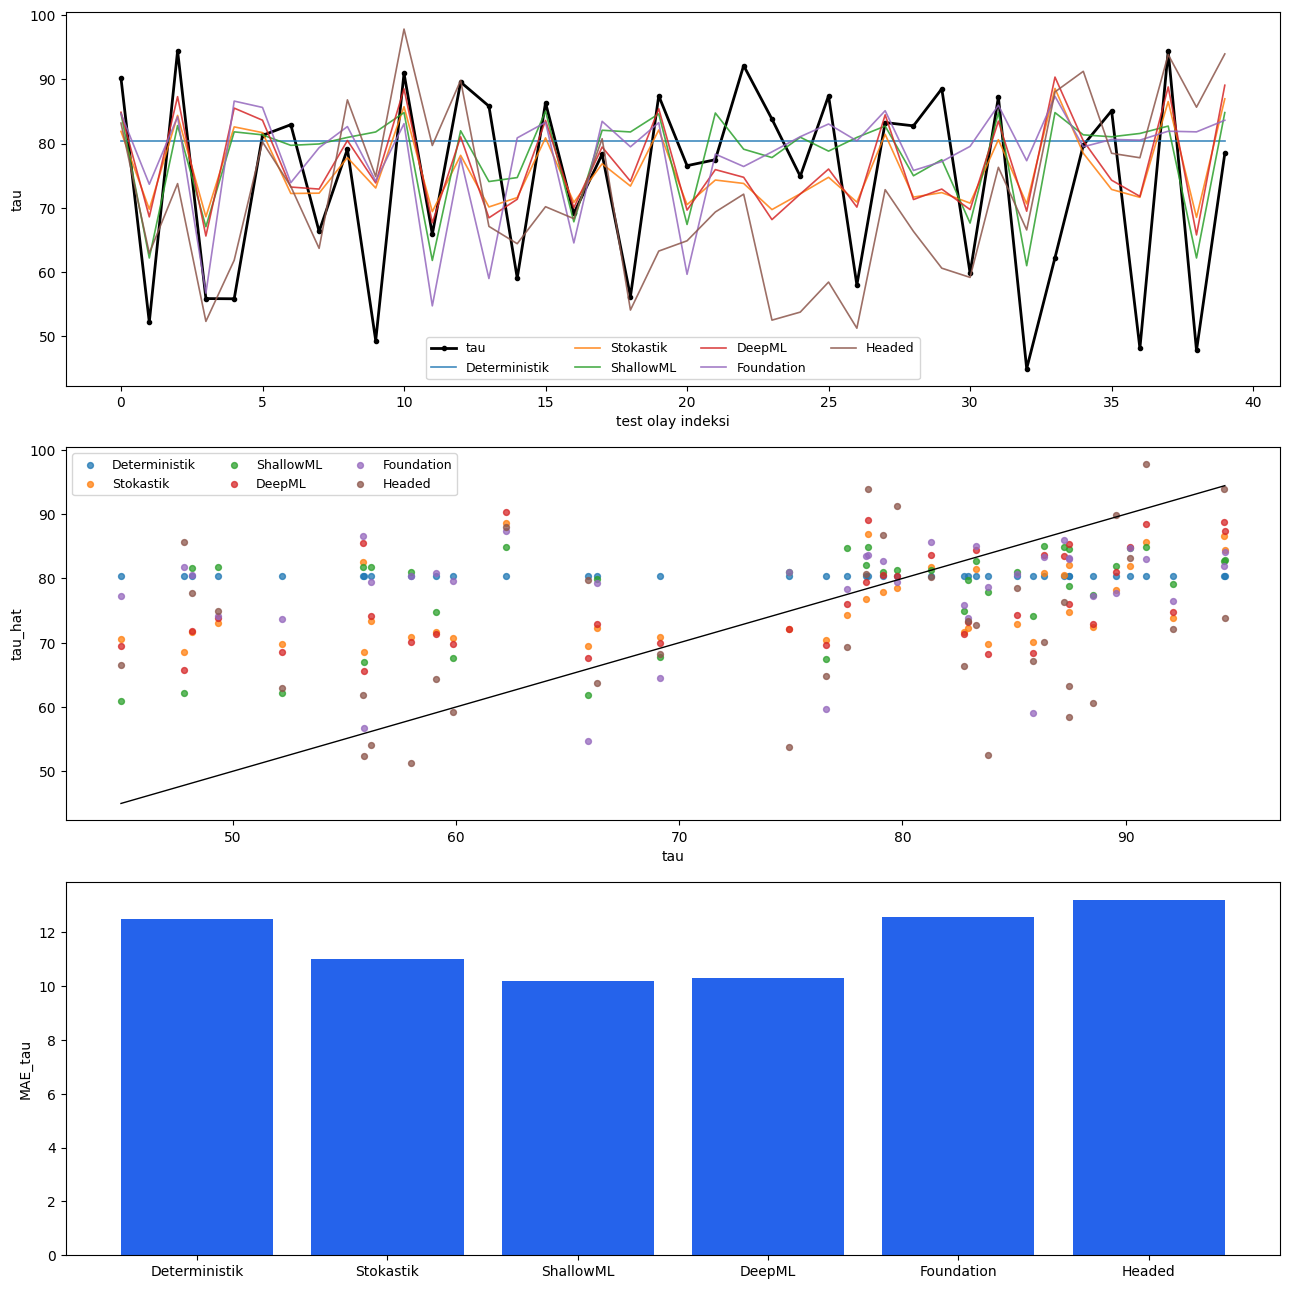

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(13, 13))

ax[0].plot(y_te, color="black", linewidth=2.0, marker="o", markersize=3, label="tau")
for m in order:
    ax[0].plot(np.asarray(TAU_HAT[m], dtype=float), linewidth=1.2, alpha=0.85, label=m)
ax[0].set_xlabel("test olay indeksi")
ax[0].set_ylabel("tau")
ax[0].legend(ncol=4, fontsize=9)

for m in order:
    ax[1].scatter(y_te, np.asarray(TAU_HAT[m], dtype=float), s=18, alpha=0.75, label=m)
ax[1].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], color="black", linewidth=1.0)
ax[1].set_xlabel("tau")
ax[1].set_ylabel("tau_hat")
ax[1].legend(ncol=3, fontsize=9)

ax[2].bar(report.index, report["MAE_tau"], color="#2563eb")
ax[2].set_ylabel("MAE_tau")

plt.tight_layout()
plt.show()